# 05 Model Tuning on Dev-Clean (Baseline MLP)

This notebook performs **model tuning** using only dev-clean data.

Tuning targets in this notebook:
- model checkpoint selection (compare multiple trained checkpoints)
- decision threshold selection (choose threshold that maximizes dev F1)

No test-clean data is used in this notebook.

### Step 1: Import libraries and set reproducibility
This step imports required packages and sets random seeds for consistent tuning runs.

In [7]:
from pathlib import Path
import sys
import random

import numpy as np
import torch
import matplotlib.pyplot as plt

SEED = 1337
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

plt.rcParams['figure.figsize'] = (10, 4)

### Step 2: Locate project root and import training modules
This step discovers the repository root, adds the Step 05 source path, and imports model/data utilities.

In [8]:
def find_project_root(start: Path) -> Path:
    start = start.resolve()
    candidates = [start] + list(start.parents)
    for c in candidates:
        if (c / 'src').exists() and (c / 'data' / 'generated').exists():
            return c
    raise FileNotFoundError('Could not locate project root')

ROOT = find_project_root(Path.cwd())
SRC_05 = ROOT / 'src' / '05_baseline_training'
if str(SRC_05) not in sys.path:
    sys.path.insert(0, str(SRC_05))

from baseline_mlp import BaselineMLP
from offline_dataset import build_dataloader

print('Project root:', ROOT)
print('Step 05 module path:', SRC_05)

Project root: /home/jasmi/Noise-Robust-Voice-Activity-Detection-FINAL
Step 05 module path: /home/jasmi/Noise-Robust-Voice-Activity-Detection-FINAL/src/05_baseline_training


### Step 3: Configure tuning settings
This step sets dev-clean paths, runtime parameters, threshold search space, and checkpoint filtering options.

In [9]:
DATA_ROOT = ROOT / 'data' / 'generated'
DEV_DIR = DATA_ROOT / 'dev'
ARTIFACTS_DIR = ROOT / 'artifacts'

BATCH_SIZE = 4096
NUM_WORKERS = 4
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MAX_FRAMES = None

# Threshold grid for tuning
THRESHOLDS = np.linspace(0.05, 0.95, 19)

 # Checkpoint discovery controls
CHECKPOINT_SUFFIXES = {'.pt', '.pth', '.ckpt'}
CHECKPOINT_NAME_CONTAINS = 'baseline_mlp'  # set None to disable name filtering
MAX_CHECKPOINTS = None  # e.g., 10 for quick runs

print('DEV_DIR            :', DEV_DIR)
print('ARTIFACTS_DIR      :', ARTIFACTS_DIR)
print('DEVICE             :', DEVICE)
print('Threshold count    :', len(THRESHOLDS))

DEV_DIR            : /home/jasmi/Noise-Robust-Voice-Activity-Detection-FINAL/data/generated/dev
ARTIFACTS_DIR      : /home/jasmi/Noise-Robust-Voice-Activity-Detection-FINAL/artifacts
DEVICE             : cuda
Threshold count    : 19


### Step 4: Build dev-clean dataloader and discover checkpoint candidates
This step creates the dev-clean dataloader and finds candidate checkpoints to compare during tuning.

In [10]:
dev_loader = build_dataloader(
    generated_dir=DEV_DIR,
    split='dev',
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
)

# Only search in artifacts to avoid environment .pth files.
ckpt_candidates = sorted(
    [
        p for p in ARTIFACTS_DIR.rglob('*')
        if p.is_file() and p.suffix in CHECKPOINT_SUFFIXES
    ]
)

if CHECKPOINT_NAME_CONTAINS:
    key = CHECKPOINT_NAME_CONTAINS.lower()
    ckpt_candidates = [p for p in ckpt_candidates if key in p.name.lower()]

if MAX_CHECKPOINTS is not None:
    ckpt_candidates = ckpt_candidates[: int(MAX_CHECKPOINTS)]

print('Dev frames:', len(dev_loader.dataset))
print('Checkpoint candidates found:', len(ckpt_candidates))
for p in ckpt_candidates[:20]:
    print(' -', p)

if not ckpt_candidates:
    raise FileNotFoundError('No checkpoint candidates found under artifacts/. Adjust filters or train models first.')

Dev frames: 1088453
Checkpoint candidates found: 1
 - /home/jasmi/Noise-Robust-Voice-Activity-Detection-FINAL/artifacts/baseline_mlp_best.pt


### Step 5: Define helper functions for model loading and metric computation
This step defines utilities to collect predictions, compute threshold metrics, and evaluate one checkpoint end-to-end.

In [11]:
def _extract_state_dict(obj):
    if isinstance(obj, dict):
        if 'state_dict' in obj and isinstance(obj['state_dict'], dict):
            return obj['state_dict']
        if 'model_state_dict' in obj and isinstance(obj['model_state_dict'], dict):
            return obj['model_state_dict']
    return obj


def _infer_mlp_shape_from_state(state_dict):
    linear_layers = []
    for k, v in state_dict.items():
        if not (k.startswith('backbone.') and k.endswith('.weight')):
            continue
        if not hasattr(v, 'shape') or len(v.shape) != 2:
            continue
        parts = k.split('.')
        if len(parts) < 3 or not parts[1].isdigit():
            continue
        idx = int(parts[1])
        out_dim, in_dim = int(v.shape[0]), int(v.shape[1])
        linear_layers.append((idx, in_dim, out_dim))

    if not linear_layers:
        raise RuntimeError('Could not infer backbone layers from checkpoint state_dict.')

    linear_layers.sort(key=lambda t: t[0])
    input_dim = linear_layers[0][1]
    hidden_dims = tuple(layer[2] for layer in linear_layers)

    # If linear indices jump by 3, checkpoint likely used Dropout in [Linear, ReLU, Dropout] pattern.
    dropout = 0.1 if len(linear_layers) >= 2 and (linear_layers[1][0] - linear_layers[0][0] == 3) else 0.0
    return input_dim, hidden_dims, dropout


def load_model_from_checkpoint(checkpoint_path: Path, device: torch.device) -> BaselineMLP:
    raw = torch.load(checkpoint_path, map_location='cpu')
    state = _extract_state_dict(raw)
    if not isinstance(state, dict):
        raise RuntimeError('Checkpoint does not contain a valid state_dict.')

    input_dim, hidden_dims, dropout = _infer_mlp_shape_from_state(state)
    model = BaselineMLP(input_dim=input_dim, hidden_dims=hidden_dims, dropout=dropout)

    model.load_state_dict(state, strict=True)
    model = model.to(device)
    model.eval()
    return model


def collect_logits_labels(loader, model, device, max_frames=None):
    logits_all = []
    labels_all = []
    seen = 0

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device, non_blocking=True)
            logits = model(x).detach().cpu().numpy()
            labels = y.detach().cpu().numpy().astype(np.int64)

            if max_frames is not None:
                remain = int(max_frames) - seen
                if remain <= 0:
                    break
                logits = logits[:remain]
                labels = labels[:remain]

            logits_all.append(logits)
            labels_all.append(labels)
            seen += len(labels)

            if max_frames is not None and seen >= int(max_frames):
                break

    if not logits_all:
        raise RuntimeError('No frames collected from loader.')

    return np.concatenate(logits_all), np.concatenate(labels_all)


def metrics_at_threshold(probs, labels, thr=0.5):
    pred = (probs >= thr).astype(np.int64)
    y = labels.astype(np.int64)

    tp = int(np.sum((pred == 1) & (y == 1)))
    tn = int(np.sum((pred == 0) & (y == 0)))
    fp = int(np.sum((pred == 1) & (y == 0)))
    fn = int(np.sum((pred == 0) & (y == 1)))

    total = max(1, tp + tn + fp + fn)
    acc = (tp + tn) / total
    prec = tp / max(1, tp + fp)
    rec = tp / max(1, tp + fn)
    f1 = (2.0 * prec * rec) / max(1e-12, (prec + rec))

    return {
        'threshold': float(thr),
        'accuracy': float(acc),
        'precision': float(prec),
        'recall': float(rec),
        'f1': float(f1),
        'tp': tp,
        'tn': tn,
        'fp': fp,
        'fn': fn,
    }


def evaluate_checkpoint_on_dev(checkpoint_path, loader, device, thresholds, max_frames=None):
    model = load_model_from_checkpoint(Path(checkpoint_path), device)
    logits, labels = collect_logits_labels(loader, model, device, max_frames=max_frames)
    probs = 1.0 / (1.0 + np.exp(-logits))

    sweep = [metrics_at_threshold(probs, labels, thr=float(t)) for t in thresholds]
    best_idx = int(np.argmax([m['f1'] for m in sweep]))
    best = sweep[best_idx]

    return {
        'checkpoint': str(checkpoint_path),
        'best_threshold': best['threshold'],
        'best_f1': best['f1'],
        'best_accuracy': best['accuracy'],
        'best_precision': best['precision'],
        'best_recall': best['recall'],
        'sweep': sweep,
    }

### Step 6: Run model-selection tuning across checkpoint candidates
This step evaluates every candidate checkpoint on dev-clean, including threshold sweep per checkpoint, then picks the best by dev F1.

In [12]:
results = []
failures = []

for i, ckpt in enumerate(ckpt_candidates, start=1):
    try:
        res = evaluate_checkpoint_on_dev(
            checkpoint_path=ckpt,
            loader=dev_loader,
            device=DEVICE,
            thresholds=THRESHOLDS,
            max_frames=MAX_FRAMES,
        )
        results.append(res)
        print(f"[{i:02d}/{len(ckpt_candidates)}] OK  {ckpt.name} | best_f1={res['best_f1']:.6f} @thr={res['best_threshold']:.2f}")
    except Exception as e:
        failures.append((str(ckpt), repr(e)))
        print(f"[{i:02d}/{len(ckpt_candidates)}] FAIL {ckpt.name} | {e}")

if not results:
    raise RuntimeError('No checkpoints were successfully evaluated.')

best_model = max(results, key=lambda r: r['best_f1'])

print('\nTuning complete.')
print('Successful evaluations:', len(results))
print('Failed evaluations    :', len(failures))
print('Best checkpoint       :', best_model['checkpoint'])
print('Best threshold        :', f"{best_model['best_threshold']:.2f}")
print('Best dev F1           :', f"{best_model['best_f1']:.6f}")

[01/1] OK  baseline_mlp_best.pt | best_f1=0.997486 @thr=0.40

Tuning complete.
Successful evaluations: 1
Failed evaluations    : 0
Best checkpoint       : /home/jasmi/Noise-Robust-Voice-Activity-Detection-FINAL/artifacts/baseline_mlp_best.pt
Best threshold        : 0.40
Best dev F1           : 0.997486


### Step 7: Show tuning leaderboard
This step prints a ranked summary so you can compare checkpoints and inspect the tuning outcome.

In [13]:
ranked = sorted(results, key=lambda r: r['best_f1'], reverse=True)

print('Top checkpoints by dev F1:')
print('-' * 110)
print(f"{'rank':>4s}  {'checkpoint':<55s}  {'thr':>5s}  {'f1':>9s}  {'acc':>9s}  {'prec':>9s}  {'rec':>9s}")
print('-' * 110)

for idx, r in enumerate(ranked, start=1):
    name = Path(r['checkpoint']).name
    print(
        f"{idx:>4d}  {name:<55.55s}  {r['best_threshold']:>5.2f}  "
        f"{r['best_f1']:>9.6f}  {r['best_accuracy']:>9.6f}  {r['best_precision']:>9.6f}  {r['best_recall']:>9.6f}"
    )

if failures:
    print('\nFailed checkpoints:')
    for ckpt, err in failures:
        print(' -', Path(ckpt).name, '|', err)

Top checkpoints by dev F1:
--------------------------------------------------------------------------------------------------------------
rank  checkpoint                                                 thr         f1        acc       prec        rec
--------------------------------------------------------------------------------------------------------------
   1  baseline_mlp_best.pt                                      0.40   0.997486   0.996528   0.999283   0.995696


### Step 8: Visualize threshold tuning for the selected checkpoint
This step plots metric curves over thresholds for the best checkpoint selected by dev-clean tuning.

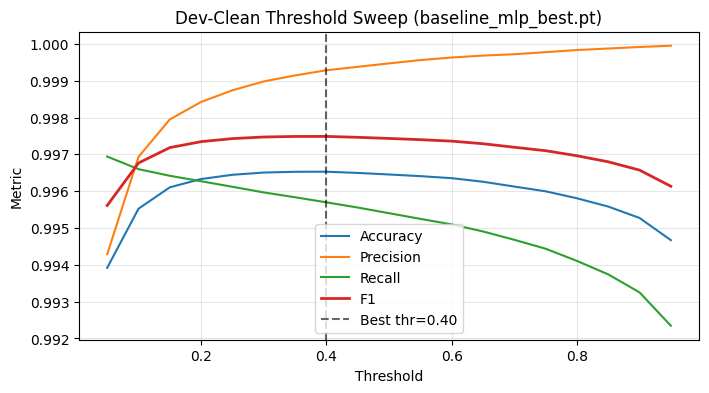

In [14]:
best_sweep = best_model['sweep']
thr = np.array([m['threshold'] for m in best_sweep])

plt.figure(figsize=(8, 4))
plt.plot(thr, [m['accuracy'] for m in best_sweep], label='Accuracy')
plt.plot(thr, [m['precision'] for m in best_sweep], label='Precision')
plt.plot(thr, [m['recall'] for m in best_sweep], label='Recall')
plt.plot(thr, [m['f1'] for m in best_sweep], label='F1', linewidth=2)
plt.axvline(
    best_model['best_threshold'],
    color='k',
    linestyle='--',
    alpha=0.6,
    label=f"Best thr={best_model['best_threshold']:.2f}",
)
plt.xlabel('Threshold')
plt.ylabel('Metric')
plt.title(f"Dev-Clean Threshold Sweep ({Path(best_model['checkpoint']).name})")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

### Step 9: Final tuned configuration
This step reports the final tuned checkpoint and threshold chosen from dev-clean only.

In [15]:
print('Selected checkpoint:', best_model['checkpoint'])
print('Selected threshold :', f"{best_model['best_threshold']:.2f}")
print('Dev metrics at selected threshold:')
print('  accuracy :', f"{best_model['best_accuracy']:.6f}")
print('  precision:', f"{best_model['best_precision']:.6f}")
print('  recall   :', f"{best_model['best_recall']:.6f}")
print('  f1       :', f"{best_model['best_f1']:.6f}")

# Optional: save tuning summary for later reference
summary_path = ARTIFACTS_DIR / 'dev_tuning_summary.txt'
summary_path.parent.mkdir(parents=True, exist_ok=True)
with open(summary_path, 'w', encoding='utf-8') as f:
    f.write('Best checkpoint: ' + best_model['checkpoint'] + '\n')
    f.write(f"Best threshold: {best_model['best_threshold']:.2f}\n")
    f.write(f"Dev accuracy: {best_model['best_accuracy']:.6f}\n")
    f.write(f"Dev precision: {best_model['best_precision']:.6f}\n")
    f.write(f"Dev recall: {best_model['best_recall']:.6f}\n")
    f.write(f"Dev F1: {best_model['best_f1']:.6f}\n")

print('Saved summary to:', summary_path)

Selected checkpoint: /home/jasmi/Noise-Robust-Voice-Activity-Detection-FINAL/artifacts/baseline_mlp_best.pt
Selected threshold : 0.40
Dev metrics at selected threshold:
  accuracy : 0.996528
  precision: 0.999283
  recall   : 0.995696
  f1       : 0.997486
Saved summary to: /home/jasmi/Noise-Robust-Voice-Activity-Detection-FINAL/artifacts/dev_tuning_summary.txt
